In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

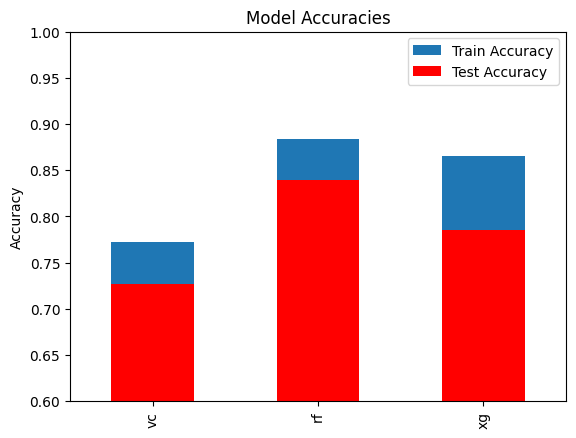

In [14]:
df = pd.read_csv('../data/lab05/q01.csv')

df.drop_duplicates()

X = df[['restecg', 'chol']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

test_accs = {}
train_accs = {}

vc = VotingClassifier(
  estimators=list({
    'rf': RandomForestClassifier(random_state=0),
    'ada': AdaBoostClassifier(random_state=0)
  }.items())
)
vc.fit(X_train, y_train)
train_accs['vc'] = vc.score(X_train, y_train)
test_accs['vc'] = vc.score(X_test, y_test)

rf = RandomForestClassifier(random_state=0)
rf.fit(X_train, y_train)
train_accs['rf'] = rf.score(X_train, y_train)
test_accs['rf'] = rf.score(X_test, y_test)

xg = XGBClassifier(random_state=0)
xg.fit(X_train, y_train)
train_accs['xg'] = xg.score(X_train, y_train)
test_accs['xg'] = xg.score(X_test, y_test)

train_accs, test_accs = pd.Series(train_accs), pd.Series(test_accs)

train_accs.plot(kind='bar', label='Train Accuracy')
test_accs.plot(kind='bar', color='red', label='Test Accuracy')
plt.ylabel('Accuracy')
plt.title('Model Accuracies')
plt.legend()
plt.ylim(0.6, 1)
plt.show()